In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import gaussian_kde
from models import CondSM
from utils import f_sm, sample_X, mse_loss_normalized, normalize_over_range


latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
print('Libraries loaded')

e_0 = 1.60217663e-19
time_scale = 1e21
out_scale = e_0 * time_scale

cuda
Libraries loaded


In [21]:
data_type = 'grad_away_1e7'
state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth', weights_only=False, map_location='cuda')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])

input_index = 0
print("Model loaded")

Model loaded


In [26]:
def mse_loss_normalized(x, y):

    x = x.float()
    y = y.float()
    x_norm = (x - x.mean()) / (x.std(unbiased=False) + 1e-8)
    y_norm = (y - y.mean()) / (y.std(unbiased=False) + 1e-8)
    
    mse = torch.mean((y_norm - x_norm)**2).item()

    return mse

def target_function(x):

    m = nn.Sigmoid()
    #return m(5*x)
    #return -torch.exp(-1*x**2)#m(x)#torch.sigmoid(5*x)
    #return np.sqrt(1 + (5*x) ** 2)
    #return np.sin(2*x)
    return x ** 2

num_curve_points = 50
num_voltages = 7
control_indices = [c_index for c_index in range(num_voltages) if c_index != input_index]
print(control_indices)
v_min = -1.5
v_max = 1.5
curve_range = torch.linspace(v_min, v_max, num_curve_points)
target_input_range = torch.linspace(v_min, v_max, num_curve_points).unsqueeze(1)
target = target_function(target_input_range)

[1, 2, 3, 4, 5, 6]


In [27]:
num_samples = 25_000
c_v_min = -1.5
c_v_max = 1.5
theta_samples = sample_X(num_samples, c_v_min, c_v_max, d=6)

model = model.to(device)
model.eval()

scores = []
for n in range(num_samples):
    input_tensor = torch.zeros(num_curve_points, num_voltages)
    control_voltages = torch.from_numpy(theta_samples[n]).float().expand(num_curve_points, -1)
    for j, c_idx in enumerate(control_indices):
        input_tensor[:, c_idx] = control_voltages[:, j]
    for k in range(num_curve_points):
        input_tensor[k, input_index] = curve_range[k]
    #print(input_tensor)
    with torch.no_grad():
        input_tensor = input_tensor.to(device)
        y = model(input_tensor).detach().cpu()

        fitness = mse_loss_normalized(y, target)
        scores.append(fitness)
print('Done')

Done


24432
0.017687391489744186
3.7975902557373047
[ 0.29236258  1.00751516 -0.46591512  1.42153888 -1.40884271 -1.47832876]


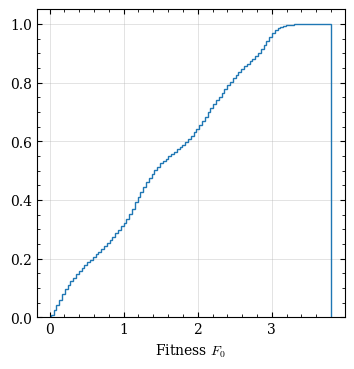

In [28]:
min_score = min(scores)
max_score = max(scores)
max_index = scores.index(max_score)
print(max_index)
print(min_score)
print(max_score)
print(theta_samples[max_index])
bins = 100
fig, ax = plt.subplots(figsize=(4,4))
ax.set_box_aspect(1)
ax.minorticks_on()
ax.tick_params(top=True, right=True, which='both')
ax.tick_params(which='both', direction='in')
ax.hist(scores, bins=bins, density=True, histtype='step', cumulative=True)
ax.grid(lw=0.5, alpha=0.5)
ax.set_xlabel(r'Fitness $F_0$')
ax.set_box_aspect(1)
#ax.legend()

#plt.savefig(f'sine_{data_type}.pdf')

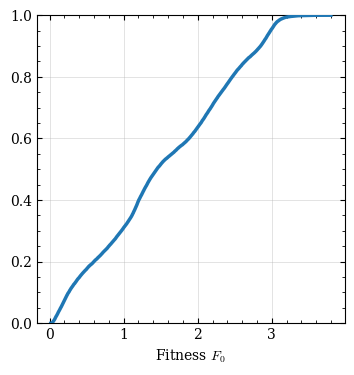

In [29]:
s = np.asarray(scores, float)
s = s[np.isfinite(s)]
s_sorted = np.sort(s)
y = np.arange(1, len(s_sorted)+1) / len(s_sorted)

fig, ax = plt.subplots(figsize=(4,4))
ax.minorticks_on()
ax.tick_params(top=True, right=True, which='both')
ax.tick_params(which='both', direction='in')
ax.plot(s_sorted, y, lw=2.5, zorder=5)
ax.set_ylim(0, 1)
ax.grid(lw=0.5, alpha=0.5)
ax.set_xlabel(r'Fitness $F_0$')
ax.set_box_aspect(1)
#plt.savefig(f'cubic_{data_type}.pdf')

[-999.999, -999.999, 0.29236258, 1.00751516, -0.46591512, 1.42153888, -1.40884271, -1.47832876]
[1, 2, 3, 4, 5, 6]


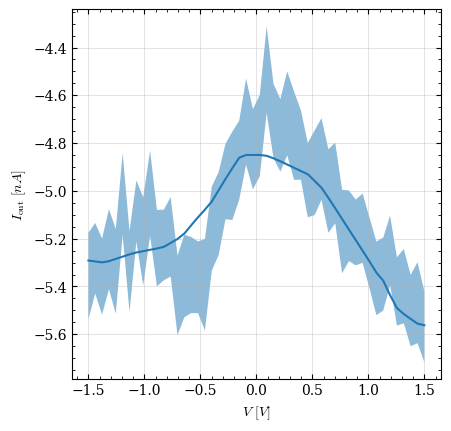

In [36]:
data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/{data_type}_parabola.npz')
I_controls = data['control']
print(I_controls.tolist())
I_out = data['current'] * time_scale
I_err = data['sem'] * time_scale
n_points = I_out.shape[0]

controls = torch.tensor([0.29236258, 1.00751516, -0.46591512, 1.42153888, -1.40884271, -1.47832876]).expand(n_points, -1)

control_indices = [i for i in range(num_voltages) if i != input_index]
print(control_indices)
input_range = torch.linspace(v_min, v_max, n_points).unsqueeze(0)

input_tensor = torch.zeros(n_points, num_voltages)
input_tensor[:, input_index] = input_range
for j, k in enumerate(control_indices):
    input_tensor[:, k] = controls[:, j]
input_tensor = input_tensor.to(device)
model.eval()
with torch.no_grad():
    y_out = model(input_tensor).detach().cpu().numpy().squeeze()

fig, ax = plt.subplots()

ax.set_box_aspect(1)
ax.minorticks_on()
ax.tick_params(direction='in', which='both')
ax.tick_params(top=True, right=True, which='both')
ax.grid(lw=0.5, alpha=0.5)
ax.set_xlabel(r'$V \, \, [V]$')
ax.set_ylabel(r'$I_{\mathrm{out}} \, \, [nA]$')

ax.plot(input_range.squeeze(), y_out*out_scale)
ax.fill_between(input_range.squeeze(), I_out - 1.96*I_err, I_out + 1.96*I_err, alpha=0.5)